# HR Analytics: Employee Performance & Attrition

**Goal:** Explore the Onyx Data *DataDNA Dataset Challenge* — Employee Performance and Productivity Dataset (Oct 2024) to understand employee attrition patterns and how they relate to performance, satisfaction, workload, and demographics.

**Dataset:** 100,000 employee records across 9 departments, with fields covering demographics, tenure, performance scores, compensation, workload (overtime/hours/projects), training, and whether the employee resigned.

**Tools:** Python (pandas, matplotlib) for exploratory analysis in this notebook, plus a companion Power BI dashboard (`Employee_Performance_Dashboard.pbix`) for interactive visualization.

---
## 1. Load & Inspect the Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [6]:
df = pd.read_excel(
    "Onyx Data - DataDNA Dataset Challenge - Employee Performance and Productivity Dataset - October 2024.xlsx"
)
print("Dataset loaded successfully!")

Dataset loaded successfully!


Quick sanity checks: shape, column types, and duplicate rows before doing any analysis.

In [7]:
df.head()

,Employee_ID,Department,Gender,Age,Job_Title,Hire_Date,Years_At_Company,Education_Level,Performance_Score,Monthly_Salary,Work_Hours_Per_Week,Projects_Handled,Overtime_Hours,Sick_Days,Remote_Work_Frequency,Team_Size,Training_Hours,Promotions,Employee_Satisfaction_Score,Resigned
0,1,IT,Male,55,Specialist,2022-01-19 08:03:05.556,2,High School,5,6750,33,32,22,2,0,14,66,0,2.63,False
1,2,Finance,Male,29,Developer,2024-04-18 08:03:05.556,0,High School,5,7500,34,34,13,14,100,12,61,2,1.72,False
2,3,Finance,Male,55,Specialist,2015-10-26 08:03:05.556,8,High School,3,5850,37,27,6,3,50,10,1,0,3.17,False
3,4,Customer Support,Female,48,Analyst,2016-10-22 08:03:05.556,7,Bachelor,2,4800,52,10,28,12,100,10,0,1,1.86,False
4,5,Engineering,Female,36,Analyst,2021-07-23 08:03:05.556,3,Bachelor,2,4800,38,11,29,13,100,15,9,1,1.25,False


In [8]:
df.shape

(100000, 20)

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 20 columns):
 #   Column                       Non-Null Count   Dtype         
---  ------                       --------------   -----         
 0   Employee_ID                  100000 non-null  int64         
 1   Department                   100000 non-null  object        
 2   Gender                       100000 non-null  object        
 3   Age                          100000 non-null  int64         
 4   Job_Title                    100000 non-null  object        
 5   Hire_Date                    100000 non-null  datetime64[ns]
 6   Years_At_Company             100000 non-null  int64         
 7   Education_Level              100000 non-null  object        
 8   Performance_Score            100000 non-null  int64         
 9   Monthly_Salary               100000 non-null  int64         
 10  Work_Hours_Per_Week          100000 non-null  int64         
 11  Projects_Handled           

In [10]:
df.duplicated().sum()

np.int64(0)

### Categorical breakdown
Department, gender, job title, education level, and how many employees resigned overall.

In [11]:
df.describe()

,Employee_ID,Age,Hire_Date,Years_At_Company,Performance_Score,Monthly_Salary,Work_Hours_Per_Week,Projects_Handled,Overtime_Hours,Sick_Days,Remote_Work_Frequency,Team_Size,Training_Hours,Promotions,Employee_Satisfaction_Score
count,100000.000000,100000.000000,100000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,50000.500000,41.029410,2019-09-15 06:20:20.916000512,4.476070,2.995430,6403.211000,44.956950,24.431170,14.514930,7.008550,50.090500,10.013560,49.506060,0.999720,2.999088
min,1.000000,22.000000,2014-09-07 08:03:05.556000,0.000000,1.000000,3850.000000,30.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,1.000000
25%,25000.750000,31.000000,2017-03-20 08:03:05.556000,2.000000,2.000000,5250.000000,37.000000,12.000000,7.000000,3.000000,25.000000,5.000000,25.000000,0.000000,2.010000
50%,50000.500000,41.000000,2019-09-21 08:03:05.556000,4.000000,3.000000,6500.000000,45.000000,24.000000,15.000000,7.000000,50.000000,10.000000,49.000000,1.000000,3.000000
75%,75000.250000,51.000000,2022-03-14 08:03:05.556000,7.000000,4.000000,7500.000000,53.000000,37.000000,22.000000,11.000000,75.000000,15.000000,75.000000,2.000000,3.990000
max,100000.000000,60.000000,2024-09-03 08:03:05.556000,10.000000,5.000000,9000.000000,60.000000,49.000000,29.000000,14.000000,100.000000,19.000000,99.000000,2.000000,5.000000
std,28867.657797,11.244121,NaN,2.869336,1.414726,1372.508717,8.942003,14.469584,8.664026,4.331591,35.351157,5.495405,28.890383,0.815872,1.150719


In [12]:
df.describe(include='object')

,Department,Gender,Job_Title,Education_Level
count,100000,100000,100000,100000
unique,9,3,7,4
top,Marketing,Male,Specialist,Bachelor
freq,11216,48031,14507,50041


In [15]:
print(df['Department'].value_counts())
print(df['Gender'].value_counts())
print(df['Job_Title'].value_counts())
print(df['Education_Level'].value_counts())
print(df['Resigned'].value_counts())

Department
Marketing           11216
Finance             11200
Operations          11181
IT                  11131
Sales               11122
Legal               11118
Customer Support    11116
HR                  10960
Engineering         10956
Name: count, dtype: int64
Gender
Male      48031
Female    48001
Other      3968
Name: count, dtype: int64
Job_Title
Specialist    14507
Manager       14325
Technician    14285
Analyst       14261
Engineer      14217
Consultant    14210
Developer     14195
Name: count, dtype: int64
Education_Level
Bachelor       50041
High School    30004
Master         14904
PhD             5051
Name: count, dtype: int64
Resigned
False    89990
True     10010
Name: count, dtype: int64


---
## 2. Attrition Overview

About **10% of employees resigned** (10,010 out of 100,000). The next step is checking whether attrition is concentrated in specific departments, education levels, or job titles — or whether it's spread evenly across the workforce.

In [16]:
df.groupby("Department")["Resigned"].mean().sort_values(ascending=False)

Department
Finance             0.105357
HR                  0.102646
Legal               0.102177
Marketing           0.100303
Operations          0.100259
Sales               0.099263
Customer Support    0.098777
Engineering         0.096477
IT                  0.095589
Name: Resigned, dtype: float64

**Visualizing attrition rate by department** (from the groupby result above):

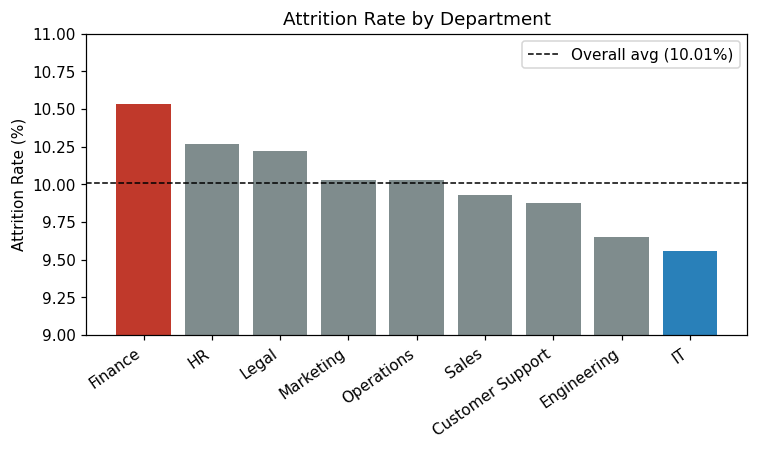

In [22]:
dept_order = df.groupby('Department')['Resigned'].mean().sort_values(ascending=False) * 100
colors = ['#c0392b' if r == dept_order.max() else ('#2980b9' if r == dept_order.min() else '#7f8c8d') for r in dept_order]

fig, ax = plt.subplots(figsize=(7,4.2))
ax.bar(dept_order.index, dept_order.values, color=colors)
ax.axhline(df['Resigned'].mean()*100, color='black', linestyle='--', linewidth=1, label=f"Overall avg ({df['Resigned'].mean()*100:.2f}%)")
ax.set_ylabel('Attrition Rate (%)')
ax.set_title('Attrition Rate by Department')
plt.xticks(rotation=35, ha='right')
ax.legend()
plt.tight_layout()
plt.show()

Attrition ranges narrowly from **9.56% (IT)** to **10.54% (Finance)** — less than a 1-point spread across all 9 departments. There's no department with a dramatically higher exit rate; the dashed line marks the company-wide average (10.01%), and every department sits close to it.

In [18]:
df['Resigned'].mean() * 100

np.float64(10.01)

In [24]:
df.groupby('Education_Level')['Resigned'].mean().sort_values(ascending=False)

Education_Level
PhD            0.103148
Bachelor       0.099978
High School    0.099953
Master         0.099772
Name: Resigned, dtype: float64

**Attrition rate by education level:**

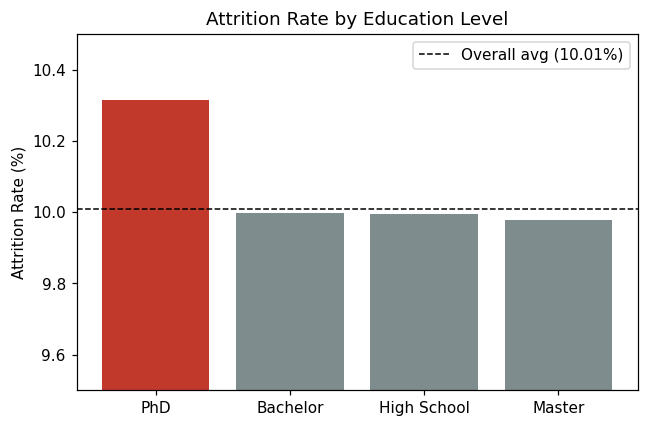

In [23]:
edu_order = df.groupby('Education_Level')['Resigned'].mean().sort_values(ascending=False) * 100
colors = ['#c0392b' if r == edu_order.max() else '#7f8c8d' for r in edu_order]

fig, ax = plt.subplots(figsize=(6,4))
ax.bar(edu_order.index, edu_order.values, color=colors)
ax.axhline(df['Resigned'].mean()*100, color='black', linestyle='--', linewidth=1, label=f"Overall avg ({df['Resigned'].mean()*100:.2f}%)")
ax.set_ylabel('Attrition Rate (%)')
ax.set_title('Attrition Rate by Education Level')
ax.legend()
plt.tight_layout()
plt.show()

Same story with education: PhD holders resign at 10.31% vs. 9.98–10.00% for everyone else — a gap small enough to be noise rather than a real effect.

In [28]:
df.groupby('Department')['Resigned'].sum().sort_values(ascending=False)

Department
Finance             1180
Legal               1136
HR                  1125
Marketing           1125
Operations          1121
Sales               1104
Customer Support    1098
IT                  1064
Engineering         1057
Name: Resigned, dtype: int64

In [29]:
df.groupby('Job_Title')['Resigned'].mean().sort_values(ascending=False)

Job_Title
Manager       0.102618
Analyst       0.101676
Consultant    0.100633
Technician    0.100035
Developer     0.099401
Specialist    0.098366
Engineer      0.097981
Name: Resigned, dtype: float64

---
## 3. What Distinguishes Employees Who Resigned?

Comparing resigned vs. current employees on satisfaction, overtime, performance, salary, and tenure:

In [19]:
df.groupby("Resigned")["Employee_Satisfaction_Score"].mean()

Resigned
False    3.000174
True     2.989325
Name: Employee_Satisfaction_Score, dtype: float64

In [20]:
df.groupby("Resigned")["Overtime_Hours"].mean() 

Resigned
False    14.508045
True     14.576823
Name: Overtime_Hours, dtype: float64

In [21]:
df.groupby('Resigned')['Performance_Score'].mean()

Resigned
False    2.996711
True     2.983916
Name: Performance_Score, dtype: float64

In [22]:
df.groupby('Resigned')['Monthly_Salary'].mean()

Resigned
False    6403.908768
True     6396.938062
Name: Monthly_Salary, dtype: float64

In [23]:
df.groupby('Resigned')['Years_At_Company'].mean()

Resigned
False    4.475319
True     4.482817
Name: Years_At_Company, dtype: float64

**% difference between resigned and stayed employees, across key metrics:**

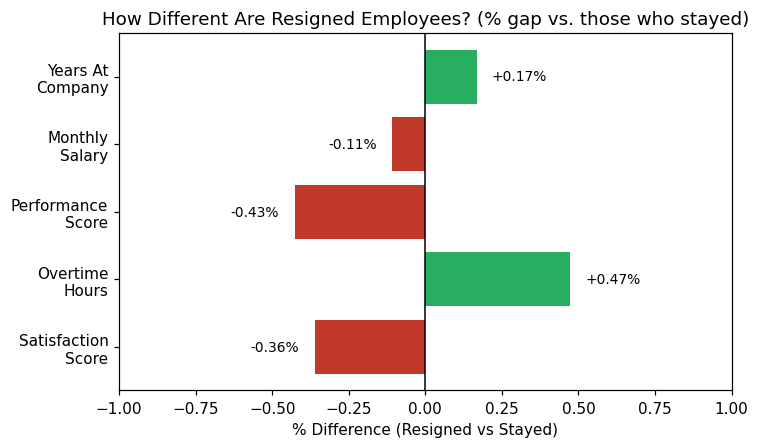

In [24]:
metrics = {
    'Satisfaction\nScore': 'Employee_Satisfaction_Score',
    'Overtime\nHours': 'Overtime_Hours',
    'Performance\nScore': 'Performance_Score',
    'Monthly\nSalary': 'Monthly_Salary',
    'Years At\nCompany': 'Years_At_Company',
}
stayed = df[df['Resigned'] == False]
left = df[df['Resigned'] == True]
pct_diff = [(left[col].mean() - stayed[col].mean()) / stayed[col].mean() * 100 for col in metrics.values()]

fig, ax = plt.subplots(figsize=(7,4.2))
colors = ['#c0392b' if v < 0 else '#27ae60' for v in pct_diff]
bars = ax.barh(list(metrics.keys()), pct_diff, color=colors)
ax.axvline(0, color='black', linewidth=1)
ax.set_xlabel('% Difference (Resigned vs Stayed)')
ax.set_title('How Different Are Resigned Employees?')
for bar, v in zip(bars, pct_diff):
    ax.text(v + (0.05 if v>=0 else -0.05), bar.get_y()+bar.get_height()/2, f'{v:+.2f}%',
            va='center', ha='left' if v>=0 else 'right', fontsize=9)
plt.tight_layout()
plt.show()

Every metric differs by **well under 0.5%** between resigned and current employees. Resigned employees aren't meaningfully less satisfied, more overworked, lower performing, lower paid, or newer to the company — the differences are within noise.

---
## 4. Workload & Training Patterns

Checking whether handling more projects relates to working longer hours, and whether higher performers receive more training.

In [30]:
df.groupby('Projects_Handled')['Work_Hours_Per_Week'].mean()

Projects_Handled
0     44.662950
1     45.006941
2     44.800385
3     45.085022
4     45.084797
5     45.157440
6     44.780723
7     45.425024
8     44.747848
9     44.982387
10    45.195249
11    44.663968
12    45.202790
13    45.316536
14    44.973697
15    44.846230
16    44.823062
17    44.947266
18    44.887468
19    45.289770
20    45.144778
21    44.926670
22    45.148185
23    44.872021
24    45.219713
25    45.085890
26    45.135121
27    44.801811
28    44.992268
29    44.791876
30    44.768852
31    44.974900
32    44.844188
33    44.983640
34    44.805414
35    44.924076
36    44.712302
37    44.634076
38    45.083293
39    45.150230
40    44.962394
41    44.959585
42    44.888782
43    44.806097
44    44.779321
45    44.749224
46    44.814350
47    44.934615
48    44.870511
49    45.180241
Name: Work_Hours_Per_Week, dtype: float64

In [31]:
df.groupby('Performance_Score')['Training_Hours'].mean()

Performance_Score
1    49.450994
2    49.283766
3    49.700185
4    49.524925
5    49.571206
Name: Training_Hours, dtype: float64

---
## 5. Key Findings

1. **Overall attrition is ~10%** (10,010 of 100,000 employees) — a stable, moderate churn rate.
2. **No department stands out.** Attrition ranges from 9.56% (IT) to 10.54% (Finance), a sub-1-point spread — attrition is evenly distributed, not concentrated in one team.
3. **Education level barely moves the needle.** PhD holders resign marginally more often (10.31%) than other groups (~9.98–10.00%), but the gap is too small to call a real driver.
4. **Satisfaction, overtime, performance, salary, and tenure are all statistically similar between resigned and current employees** (all differences under 0.5%). In this dataset, none of the usual 'obvious' attrition drivers actually separate leavers from stayers.
5. **Workload metrics (hours worked vs. projects handled) and training hours by performance score are essentially flat** — more projects doesn't mean longer hours, and top performers don't receive noticeably more training than lower performers.

**Takeaway:** In this dataset, attrition looks close to **random with respect to the variables captured** — department, education, satisfaction, workload, performance, salary, and tenure. If this were a real company, the practical implication is that HR would need to look beyond these standard HR metrics (e.g. manager quality, career growth, external offers, commute, team dynamics) to understand *why* people actually leave, since none of the usual suspects explain it here.

**Companion dashboard:** `Employee_Performance_Dashboard.pbix` — an interactive Power BI dashboard built on the same dataset for exploring these breakdowns visually (see `/screenshots` in the repo).